In [3]:
# EdgeGuard - Person vs Empty Classifier (Colab)


In [18]:
# Imports and setup
import os
import io
import zipfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [21]:
!pip -q install tensorflow==2.21.0 scikit-learn matplotlib pillow

In [22]:
# Upload dataset zip
from google.colab import files
uploaded = files.upload()

Saving processed.zip to processed (1).zip


In [23]:
# Unzip Dataset
zip_name = next(iter(uploaded.keys()))

extract_dir = Path("/content/edgeguard_data")
extract_dir.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_name, "r") as zf:
    zf.extractall(extract_dir)

if (extract_dir / "processed").exists():
    data_dir = extract_dir / "processed"
else:
    data_dir = extract_dir

print("Data directory:", data_dir)
print("Class folders:", [p.name for p in data_dir.iterdir() if p.is_dir()])

Data directory: /content/edgeguard_data/processed
Class folders: ['empty', 'person']


In [24]:
# Check dataset counts
class_counts = {}
for class_dir in sorted([p for p in data_dir.iterdir() if p.is_dir()]):
    class_counts[class_dir.name] = len(list(class_dir.glob("*")))

class_counts

{'empty': 397, 'person': 199}

In [25]:
# Training Config
IMG_SIZE = (96, 96)
BATCH_SIZE = 16
VAL_SPLIT = 0.2
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

In [26]:
# Create train and validation datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
)

class_names = train_ds.class_names
print("Class names:", class_names)

Found 596 files belonging to 2 classes.
Using 477 files for training.
Found 596 files belonging to 2 classes.
Using 119 files for validation.
Class names: ['empty', 'person']


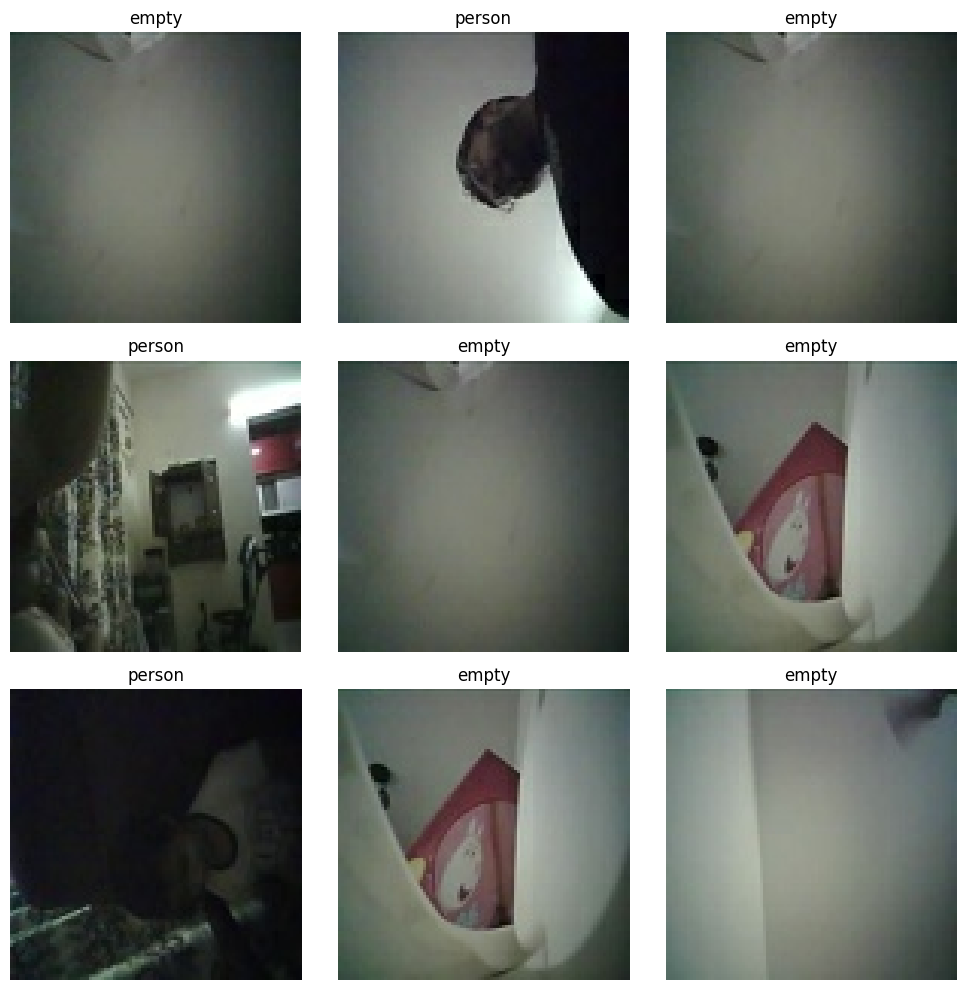

In [27]:
# Preview Image
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i].numpy()[0])])
        plt.axis("off")
plt.tight_layout()
plt.show()

In [28]:
# Compute Class Weight
y_train = []
for _, labels in train_ds.unbatch():
    y_train.append(int(labels.numpy()[0]))
y_train = np.array(y_train)

classes = np.array([0, 1])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight = {int(c): float(w) for c, w in zip(classes, weights)}

print("Class weights:", class_weight)
print("Class mapping:", dict(enumerate(class_names)))

Class weights: {0: 0.75, 1: 1.5}
Class mapping: {0: 'empty', 1: 'person'}


In [29]:
# Optimize dataset pipeline
train_ds = train_ds.cache().shuffle(512).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

In [30]:
# Build the training model
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.10),
], name="augmentation")

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet",
)

base_model.trainable = False

gap_layer = tf.keras.layers.GlobalAveragePooling2D(name="gap")
dropout_layer = tf.keras.layers.Dropout(0.2, name="dropout")
classifier_layer = tf.keras.layers.Dense(1, activation="sigmoid", name="person_score")

train_inputs = tf.keras.Input(shape=IMG_SIZE + (3,), name="input_image")
x = data_augmentation(train_inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = gap_layer(x)
x = dropout_layer(x)
train_outputs = classifier_layer(x)

model = tf.keras.Model(train_inputs, train_outputs, name="edgeguard_person_classifier")
model.summary()

Model: "edgeguard_person_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ person_score (Dense)            │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [31]:
# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc"),
    ],
)

In [32]:
# Train the classification head
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1,
    ),
]

history_1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weight,
    callbacks=callbacks,
)

Epoch 1/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.8281 - auc: 0.9165 - loss: 0.3763 - precision: 0.7104 - recall: 0.8176 - val_accuracy: 0.9916 - val_auc: 0.9886 - val_loss: 0.0956 - val_precision: 1.0000 - val_recall: 0.9750 - learning_rate: 0.0010
Epoch 2/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9916 - auc: 0.9997 - loss: 0.0698 - precision: 0.9874 - recall: 0.9874 - val_accuracy: 0.9916 - val_auc: 0.9929 - val_loss: 0.0541 - val_precision: 1.0000 - val_recall: 0.9750 - learning_rate: 0.0010
Epoch 3/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9916 - auc: 1.0000 - loss: 0.0476 - precision: 1.0000 - recall: 0.9748 - val_accuracy: 0.9916 - val_auc: 0.9951 - val_loss: 0.0477 - val_precision: 1.0000 - val_recall: 0.9750 - learning_rate: 0.0010
Epoch 4/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9958 - auc: 0.9999 - loss: 0.0334 - precision: 1.0000 - recall: 0.9874 - val_accuracy: 0.9916 - val_auc: 0.9959 - val_loss: 0.0442 - val_pre

In [33]:
# Fine-tune deeper layers
base_model.trainable = True

fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc"),
    ],
)

history_2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weight,
    callbacks=callbacks,
)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 16s 95ms/step - accuracy: 0.3857 - auc: 0.9773 - loss: 1.3149 - precision: 0.3518 - recall: 1.0000 - val_accuracy: 0.9916 - val_auc: 0.9875 - val_loss: 0.0541 - val_precision: 1.0000 - val_recall: 0.9750 - learning_rate: 1.0000e-05
Epoch 2/10
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5716 - auc: 0.9969 - loss: 0.6626 - precision: 0.4730 - recall: 1.0000
Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.5157 - auc: 0.9935 - loss: 0.7703 - precision: 0.4077 - recall: 1.0000 - val_accuracy: 0.9916 - val_auc: 0.9875 - val_loss: 0.0614 - val_precision: 1.0000 - val_recall: 0.9750 - learning_rate: 1.0000e-05
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.6625 - auc: 0.9903 - loss: 0.5362 - precision: 0.4969 - recall: 1.0000 - val_accuracy: 0.9916 - val_auc: 0.9875 - val_loss: 0.0616 - val_precision: 1.0000 - val_recall: 0.9750 - learning_rate: 5.

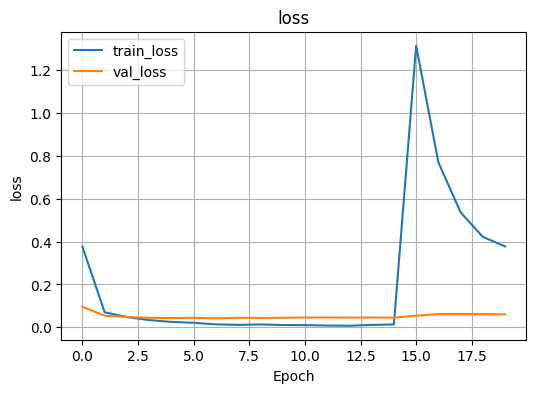

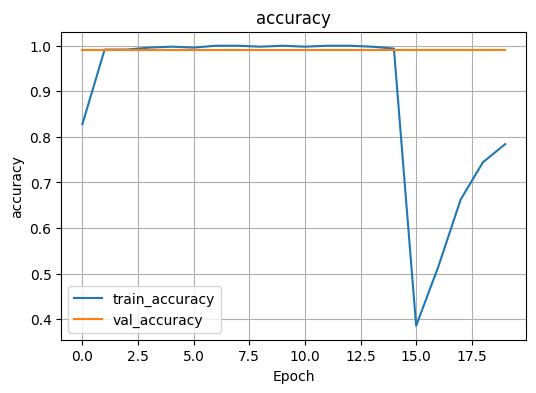

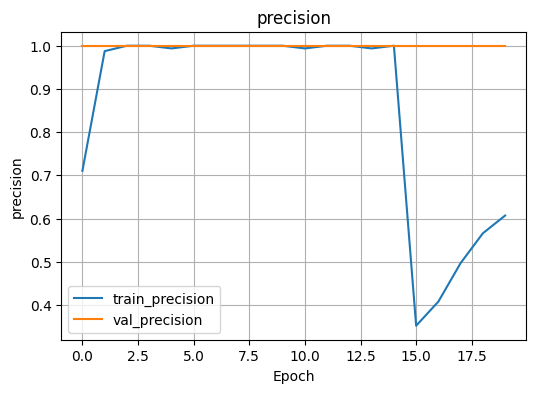

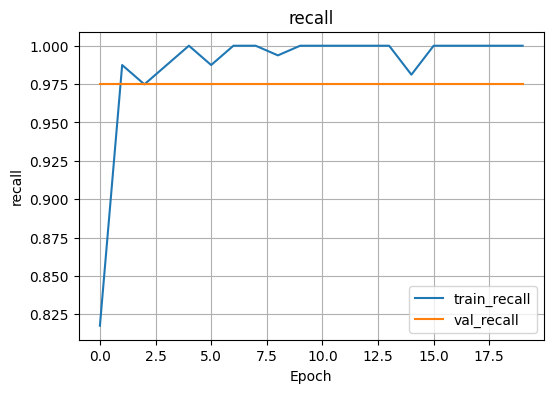

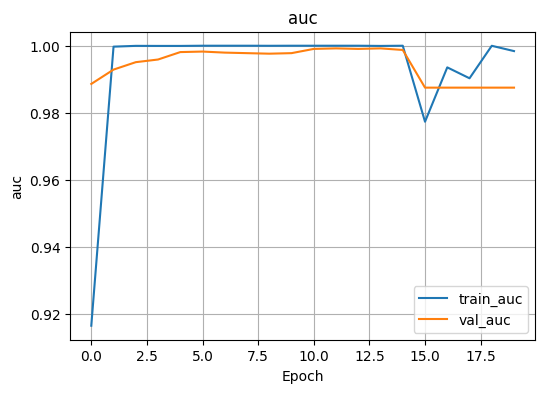

In [34]:
# Plot training history
def merge_histories(*histories):
    merged = {}
    for hist in histories:
        for k, v in hist.history.items():
            merged.setdefault(k, []).extend(v)
    return merged

merged = merge_histories(history_1, history_2)

for metric in ["loss", "accuracy", "precision", "recall", "auc"]:
    plt.figure(figsize=(6, 4))
    plt.plot(merged.get(metric, []), label=f"train_{metric}")
    plt.plot(merged.get(f"val_{metric}", []), label=f"val_{metric}")
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.title(metric)
    plt.legend()
    plt.grid(True)
    plt.show()

In [35]:
#Evaluate Training Model
val_metrics = model.evaluate(val_ds, return_dict=True)
val_metrics

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9916 - auc: 0.9875 - loss: 0.0541 - precision: 1.0000 - recall: 0.9750


{'accuracy': 0.9915966391563416,
 'auc': 0.987500011920929,
 'loss': 0.05405183136463165,
 'precision': 1.0,
 'recall': 0.9750000238418579}

In [36]:
# Validation predictions and report
y_true = []
y_prob = []

for images, labels in val_ds:
    probs = model.predict(images, verbose=0).reshape(-1)
    y_prob.extend(probs.tolist())
    y_true.extend(labels.numpy().reshape(-1).astype(int).tolist())

y_true = np.array(y_true)
y_prob = np.array(y_prob)
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

              precision    recall  f1-score   support

       empty     0.9875    1.0000    0.9937        79
      person     1.0000    0.9750    0.9873        40

    accuracy                         0.9916       119
   macro avg     0.9938    0.9875    0.9905       119
weighted avg     0.9917    0.9916    0.9916       119



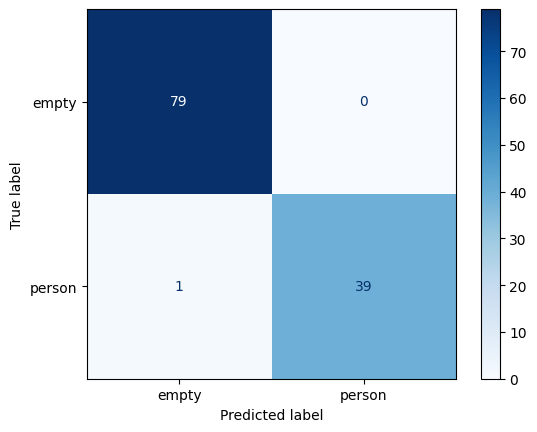

In [37]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues")
plt.show()

In [38]:
# Optional threshold tuning
thresholds = np.arange(0.10, 0.91, 0.05)

print("threshold | precision_person | recall_person | f1_person")
for thr in thresholds:
    preds = (y_prob >= thr).astype(int)
    report = classification_report(
        y_true,
        preds,
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )
    person_metrics = report["person"]
    print(
        f"{thr:8.2f} | "
        f"{person_metrics['precision']:16.4f} | "
        f"{person_metrics['recall']:13.4f} | "
        f"{person_metrics['f1-score']:9.4f}"
    )

threshold | precision_person | recall_person | f1_person
    0.10 |           1.0000 |        0.9750 |    0.9873
    0.15 |           1.0000 |        0.9750 |    0.9873
    0.20 |           1.0000 |        0.9750 |    0.9873
    0.25 |           1.0000 |        0.9750 |    0.9873
    0.30 |           1.0000 |        0.9750 |    0.9873
    0.35 |           1.0000 |        0.9750 |    0.9873
    0.40 |           1.0000 |        0.9750 |    0.9873
    0.45 |           1.0000 |        0.9750 |    0.9873
    0.50 |           1.0000 |        0.9750 |    0.9873
    0.55 |           1.0000 |        0.9750 |    0.9873
    0.60 |           1.0000 |        0.9750 |    0.9873
    0.65 |           1.0000 |        0.9750 |    0.9873
    0.70 |           1.0000 |        0.9750 |    0.9873
    0.75 |           1.0000 |        0.9750 |    0.9873
    0.80 |           1.0000 |        0.9500 |    0.9744
    0.85 |           1.0000 |        0.9500 |    0.9744
    0.90 |           1.0000 |        0.9500 |  

In [39]:
# Build the export model without augmentation
export_inputs = tf.keras.Input(shape=IMG_SIZE + (3,), name="input_image")
y = tf.keras.applications.mobilenet_v2.preprocess_input(export_inputs)
y = base_model(y, training=False)
y = gap_layer(y)
y = classifier_layer(y)

export_model = tf.keras.Model(export_inputs, y, name="edgeguard_person_classifier_export")
export_model.summary()

Model: "edgeguard_person_classifier_export"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_2 (TrueDivide)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_2 (Subtract)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ person_score (Dense)            │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,862,721 (7.11 MB)

 Non-trainable params: 396,544 (1.51 MB)

In [40]:
# Quick sanity check on export model
for images, _ in val_ds.take(1):
    original_out = model(images, training=False).numpy().reshape(-1)
    export_out = export_model(images, training=False).numpy().reshape(-1)

print("Mean abs diff:", np.mean(np.abs(original_out - export_out)))
print("Max abs diff :", np.max(np.abs(original_out - export_out)))

Mean abs diff: 0.0
Max abs diff : 0.0


In [41]:
# Save Artifacts
export_dir = Path("/content/edgeguard_exports")
export_dir.mkdir(parents=True, exist_ok=True)

keras_path = export_dir / "edgeguard_person_classifier.keras"
export_keras_path = export_dir / "edgeguard_person_classifier_export.keras"

model.save(keras_path)
export_model.save(export_keras_path)

print("Saved training model:", keras_path)
print("Saved export model  :", export_keras_path)

Saved training model: /content/edgeguard_exports/edgeguard_person_classifier.keras
Saved export model  : /content/edgeguard_exports/edgeguard_person_classifier_export.keras


In [42]:
# Convert export model to float TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(export_model)
float_tflite_model = converter.convert()

float_tflite_path = export_dir / "edgeguard_person_classifier_float.tflite"
float_tflite_path.write_bytes(float_tflite_model)

print("Float TFLite size (bytes):", float_tflite_path.stat().st_size)

Saved artifact at '/tmp/tmpidbhe_iv'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  138111949948880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138111949950992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138111949950800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138111949950416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138111949951568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138111949950224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138111949951184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138111949951376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138111949950032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138111949952528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138111949951952: 

In [43]:
# Convert export model to INT8 TFLite
def representative_data_gen():
    for images, _ in train_ds.unbatch().batch(1).take(100):
        images = tf.cast(images, tf.float32)
        yield [images]

converter = tf.lite.TFLiteConverter.from_keras_model(export_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

int8_tflite_model = converter.convert()

int8_tflite_path = export_dir / "edgeguard_person_classifier_int8.tflite"
int8_tflite_path.write_bytes(int8_tflite_model)

print("INT8 TFLite size (bytes):", int8_tflite_path.stat().st_size)

Saved artifact at '/tmp/tmp71xjkipw'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  138111949948880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138111949950992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138111949950800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138111949950416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138111949951568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138111949950224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138111949951184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138111949951376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138111949950032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138111949952528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138111949951952: 

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


INT8 TFLite size (bytes): 2744160


In [44]:
# Inspect TFLite models
print("Float model:", float_tflite_path)
print("INT8 model :", int8_tflite_path)

Float model: /content/edgeguard_exports/edgeguard_person_classifier_float.tflite
INT8 model : /content/edgeguard_exports/edgeguard_person_classifier_int8.tflite


In [45]:
# Sanity check float TFLite model
interpreter = tf.lite.Interpreter(model_path=str(float_tflite_path))
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input details:", input_details)
print("Output details:", output_details)

Input details: [{'name': 'serving_default_input_image:0', 'index': 0, 'shape': array([ 1, 96, 96,  3], dtype=int32), 'shape_signature': array([-1, 96, 96,  3], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0, 'block_size': 0}, 'sparsity_parameters': {}}]
Output details: [{'name': 'StatefulPartitionedCall_1:0', 'index': 176, 'shape': array([1, 1], dtype=int32), 'shape_signature': array([-1,  1], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0, 'block_size': 0}, 'sparsity_parameters': {}}]


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [46]:
# Run one sample through float TFLite
for images, labels in val_ds.take(1):
    sample = images[0:1].numpy().astype(np.float32)
    sample_label = int(labels[0].numpy()[0])

interpreter.set_tensor(input_details[0]["index"], sample)
interpreter.invoke()
tflite_output = interpreter.get_tensor(output_details[0]["index"])[0][0]

print("True label:", class_names[sample_label])
print("TFLite score:", float(tflite_output))

True label: empty
TFLite score: 0.0002633535477798432


In [47]:
# Download artifacts
from google.colab import files

files.download(str(keras_path))
files.download(str(export_keras_path))
files.download(str(float_tflite_path))
files.download(str(int8_tflite_path))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>